In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = "retina"

### **Section One:** Computing Convexity Ratios and Building the Data Frame

In [2]:
# congressional district boundaries cong116 data set: https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
dists_map = gpd.read_file("data_2018/cb_2018_us_cd116_500k.shp", engine="fiona")

# congressional district election data set: https://github.com/PrincetonUniversity/gerrymandertests/tree/master/election_data
dists_demo = gpd.read_file("data_2018/congressional_election_results_post1948.csv", engine="fiona")

In [3]:
# remove demo data from years besides 2018
dists_demo = dists_demo[dists_demo["Year"] == "2018"]
dists_demo["codes"] = dists_demo["State"] + dists_demo["District"]
dists_demo = dists_demo.drop(columns = ["State", "District"])

In [4]:
# functions to compute convex hull and convexity ratio
# input state, district number as strings

# plot a specific district
def dist_plot(state, d):
    dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)].plot(figsize = (10, 10))

# compute and plot convex hull
def comp_hull(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    return(hull)

def plot_hull(state, d):
    hull = comp_hull(state, d)
    hull.plot(figsize = (20, 20))

# compute and plot region of convex hull outside of the district
def hull_overlap(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

def plot_overlap(state, d):
    overlap = hull_overlap(state, d)
    overlap.plot(figsize = (20, 20))

# compute and plot region of convex hull outside of district but within state lines
def hull_intersection(state, d):
    state_plot = dists_map[dists_map["State"] == state]
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state_plot, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

def plot_intersection(state, d):
    intersection = hull_intersection(state, d)
    intersection.plot(figsize = (20, 20))

# compute area of convex hull outside of district but within state lines
def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = sum(hull_pts.geometry.to_crs("epsg:32633").area)
    return(hull)

# compute ratio of area of convex hull outside of district but within state lines to area of district
# idea: higher ratio implies that the district is less convex
# this function is unnecessary as all values are stored in df
def hull_ratio(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]["Area"]
    hull = hull_area(state, d)
    ratio = hull / dist
    return(ratio)

In [5]:
# fips to state abbreviations
fips_to_state = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA",
    "08": "CO", "09": "CT", "10": "DE", "12": "FL", "13": "GA", 
    "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", 
    "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", 
    "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", 
    "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", 
    "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", 
    "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", 
    "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", 
    "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

dists_map["State"] = dists_map["STATEFP"].map(fips_to_state)

# standardize district numbering across dfs 
# remove leading zeros
dists_map["District"] = list(map(lambda s: s.lstrip("0"), dists_map["CD116FP"]))
# for states with only one district, refer to that distict as "1" rather than null
dists_map["District"] = dists_map["District"].apply(lambda x: "1" if x == "" else x)

# remove us territories
dists_map = dists_map.dropna()

In [ ]:
# compute hull areas for all district and append to df
hull_areas = []
for i in range(0, len(dists_map)):
    state = dists_map["State"].iloc[i]
    d = dists_map["District"].iloc[i]
    hull = hull_area(state, d)
    hull_areas.append(hull)

dists_map["hull_area"] = hull_areas

In [ ]:
# change coordinate system (necessary for computing accurate areas)
dists_map["geom_crs"] = dists_map["geometry"].geometry.to_crs("epsg:32633")

# compute district areas
dists_map["Area"] = dists_map["geom_crs"].area

# compute convexity ratios
dists_map["Ratio"] = dists_map["hull_area"] / dists_map["Area"]

# create unique identifier for each district that combines state and district number (necessary for merging dfs)
dists_map["codes"] = dists_map["State"] + dists_map["District"]

In [13]:
# merge dfs on state and district
dists = pd.merge(dists_demo, dists_map, on = "codes", how = "outer")

In [14]:
# compute total percentage democrats for each state and append to df
dem_percs = []
for i in range(0, len(dists)):
    state = dists["State"].iloc[i]
    d = dists["District"].iloc[i]
    dem_num = sum(dists[dists["State"] == state]["Dem Votes"].astype(float))
    rep_num = sum(dists[dists["State"] == state]["GOP Votes"].astype(float))
    dem_perc = dem_num / (dem_num + rep_num)
    dem_percs.append(dem_perc)
    
dists["dem_percs"] = dem_percs

In [16]:
# make geo df (necessary for plotting)
dists_geo = gpd.GeoDataFrame(dists)

In [17]:
# transform entries of "d voteshare" and "dem_percs" from objects to floats (necessary for plotting)
dists_geo["D Voteshare"] = dists_geo["D Voteshare"].astype(float)
dists_geo["dem_percs"] = dists_geo["dem_percs"].astype(float)

In [18]:
# create indicator column for whether over 50% of state's population voted democratic
dists_geo["st_party"] = dists_geo["dem_percs"] >= 0.5

### **Section Two:** Plotting Various Things

Text(0, 0.5, 'Frequency')

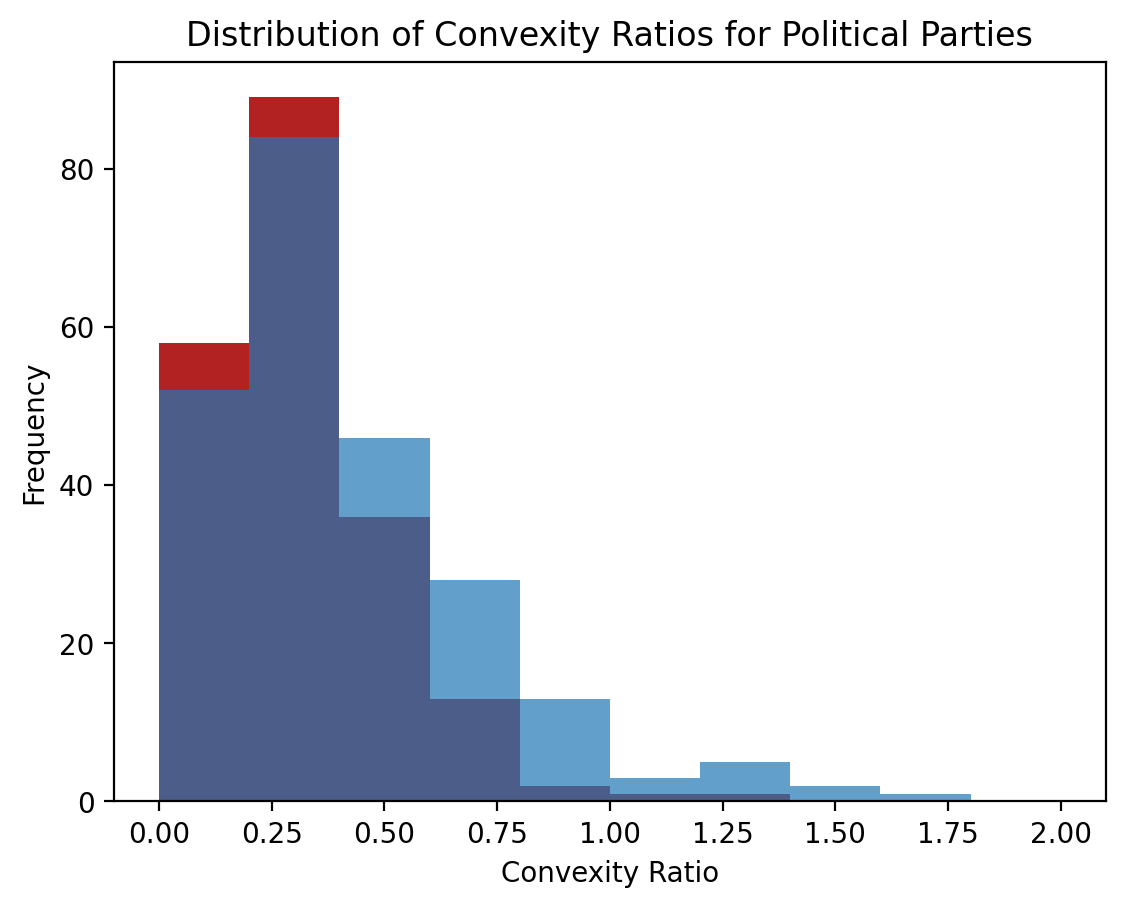

In [19]:
# histogram which compares the distribution of convexity scores across districts which elected democratic or republican representatives
dists[dists["Party"] == "R"]["Ratio"].hist(grid = False, 
                                           bins = 10, 
                                           color = "firebrick", 
                                           range = [0,2])
dists[dists["Party"] == "D"]["Ratio"].hist(grid = False, 
                                           bins = 10, 
                                           alpha = 0.7, 
                                           range = [0,2])
plt.title("Distribution of Convexity Ratios for Political Parties")
plt.xlabel("Convexity Ratio")
plt.ylabel("Frequency")

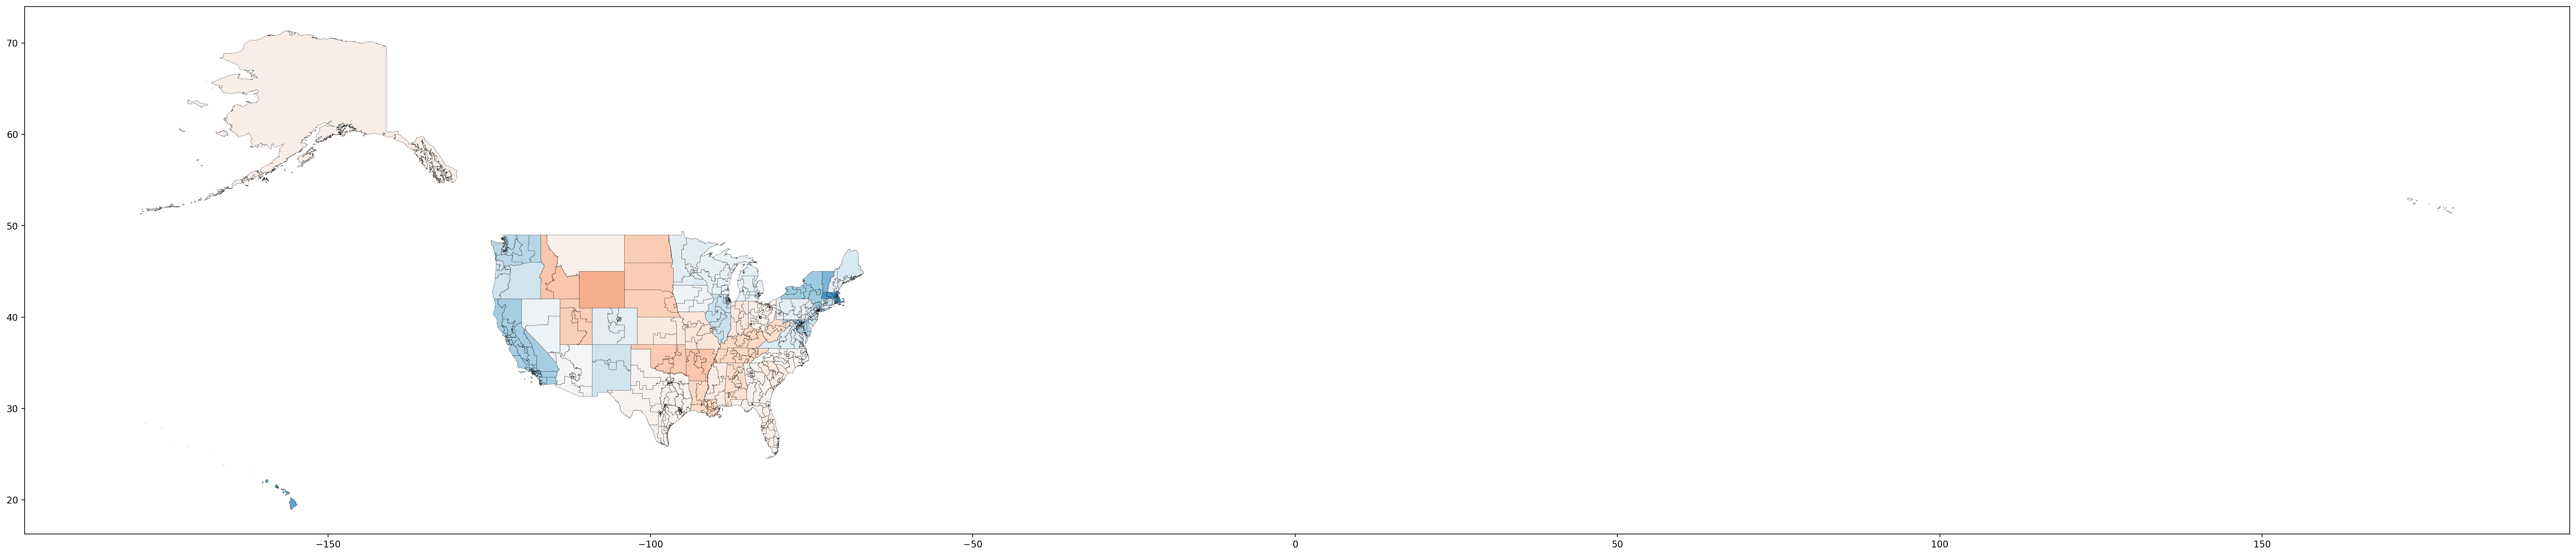

In [21]:
# plot full us
# coloring based on state's total proportion of democratic voters

dists_geo.plot(
    column = "dem_percs",
    #legend = True,
    figsize = (50, 50),
    edgecolor = "black",
    linewidth = 0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

In [22]:
# plot full us 
# coloring based on each district's proportion of democratic voters

dists_geo.plot(
    column="D Voteshare",
    #legend=True,
    figsize=(100, 100),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.30,
    vmax = 0.70
);

In [24]:
# plot full us 
# coloring based on each district's convexity ratio

dists_map.plot(
    column="Ratio",
    #legend=True,
    figsize=(100, 100),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

Text(29.000000000000007, 0.5, 'Convexity Ratio')

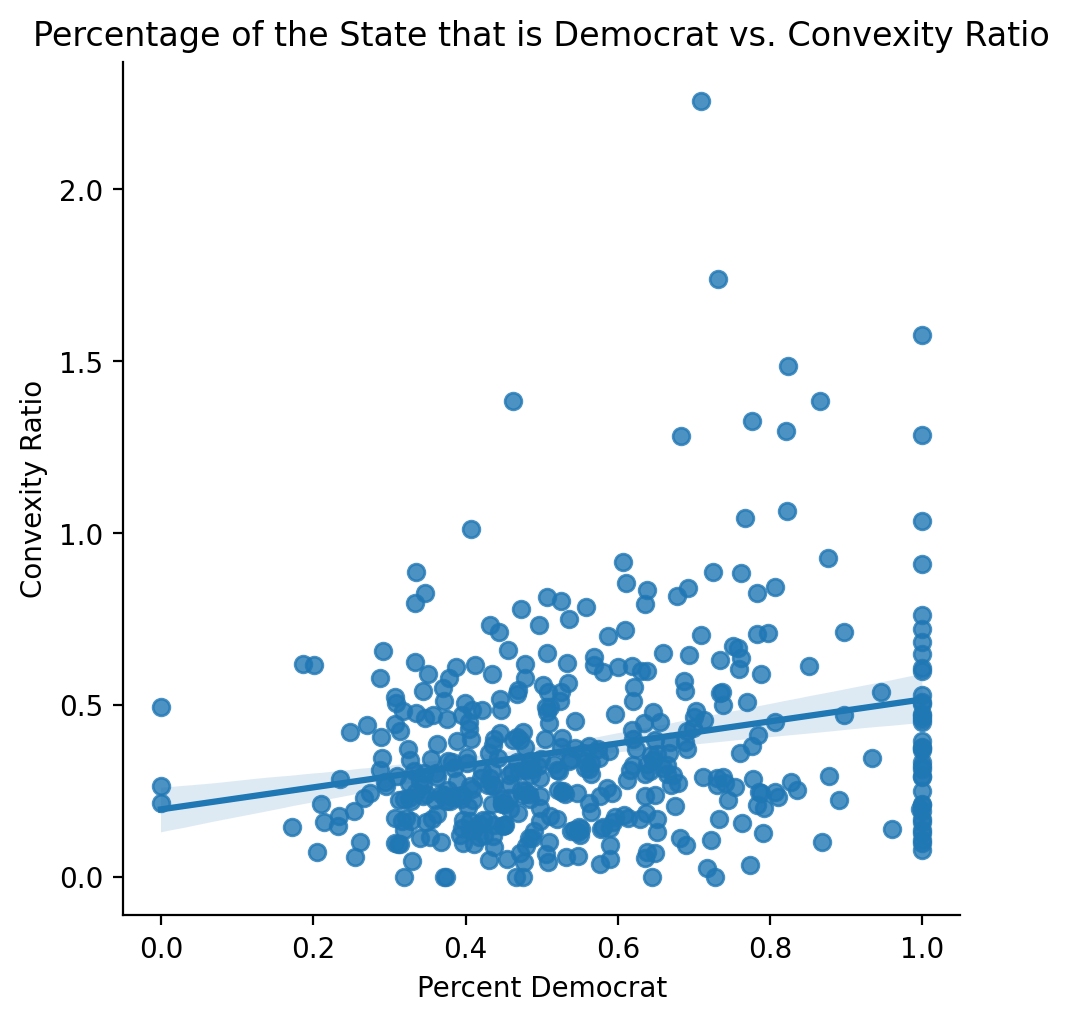

In [25]:
# compare a specific district's proportion of democratic voters with its convexity scores
# appears to be an upward trend
# possible explanation: urban districts are more likely to be democratic and have nastier shapes because they are smaller

sns.lmplot(x = "D Voteshare", 
            y = "Ratio", 
            data = dists_geo,
            ci = 95,
            palette = ["firebrick", "dodgerblue"],
            legend = False)
plt.title("Percentage of the State that is Democrat vs. Convexity Ratio")
plt.xlabel("Percent Democrat")
plt.ylabel("Convexity Ratio")

Text(29.000000000000007, 0.5, 'Convexity Ratio')

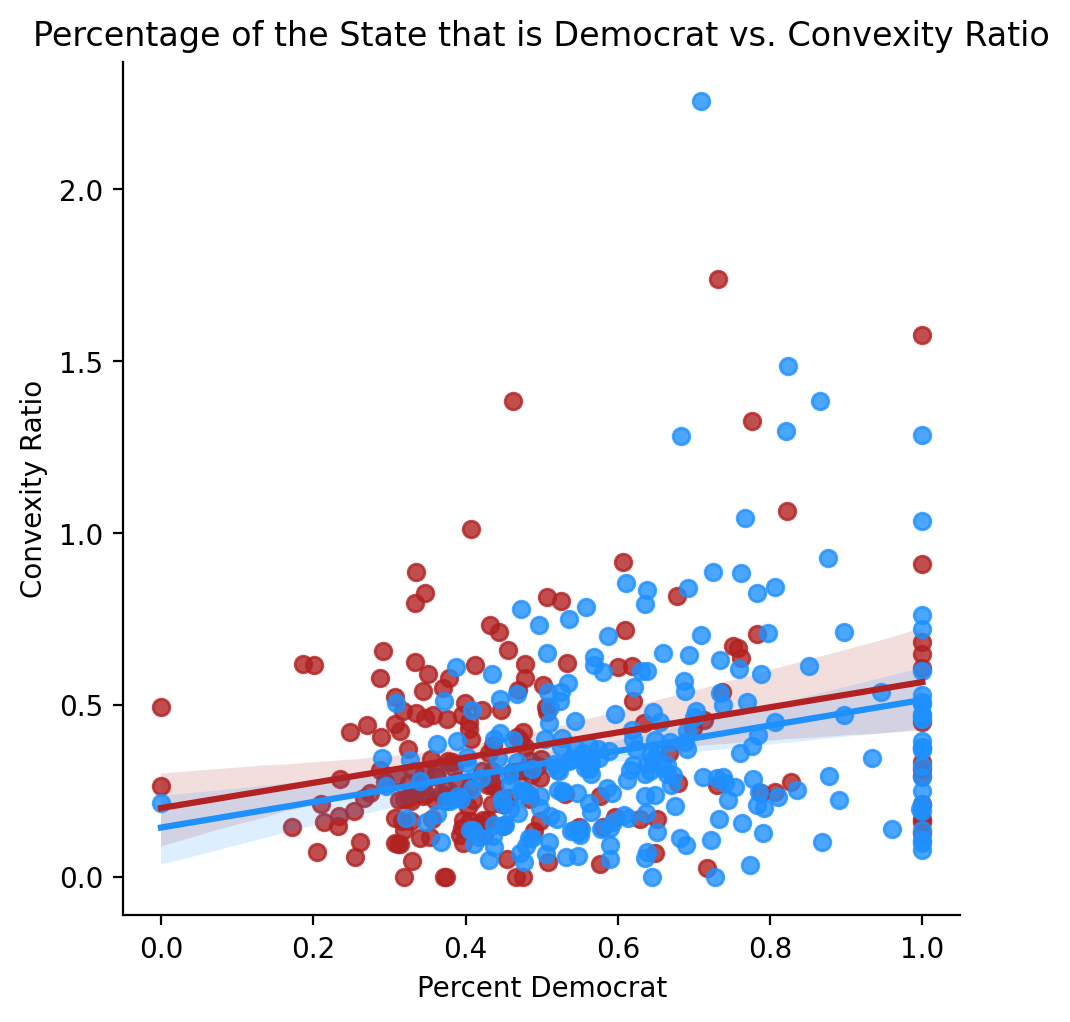

In [26]:
# compare a specific district's proportion of democratic voters with its convexity scores
# additionally, this graph separates states with majprity democratic or repiblican voters
# no major difference between the groups

sns.lmplot(x = "D Voteshare", 
            y = "Ratio", 
            data = dists_geo,
            ci = 95,
            hue = "st_party",
            palette = ["firebrick", "dodgerblue"],
            legend = False)
plt.title("Percentage of the State that is Democrat vs. Convexity Ratio")
plt.xlabel("Percent Democrat")
plt.ylabel("Convexity Ratio")

Text(29.000000000000007, 0.5, 'Convexity Ratio')

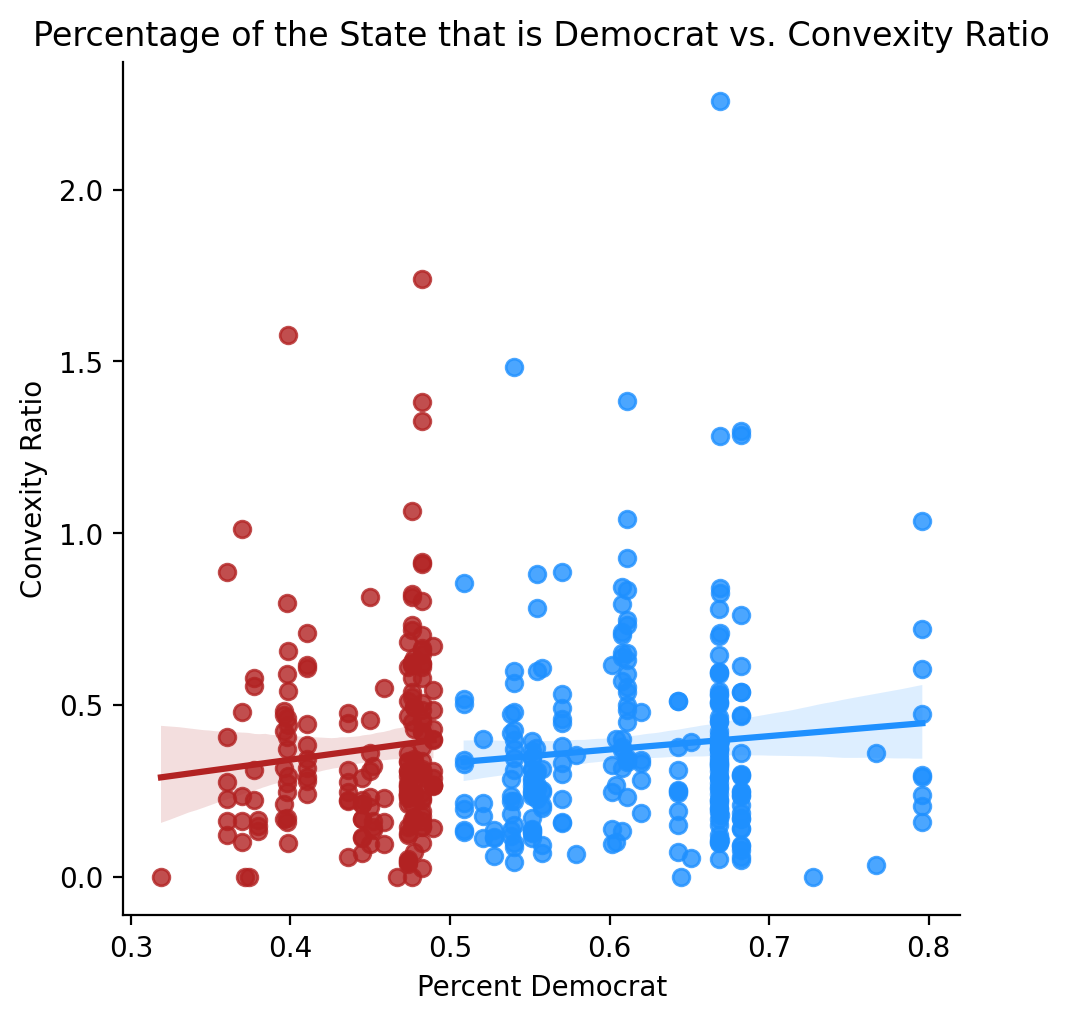

In [27]:
# plot comparing state's proportion of democratic voters with its districts' convexity scores
# divide into groups based on if state has majority democratic voters
# run individual regressions on these two groups with confidence intervals
# regression lines are not that different and confidence intervals overlap, so little evidence of a systematic difference

sns.lmplot(x = "dem_percs", 
            y = "Ratio", 
            data = dists_geo,
            ci = 95,
            hue = "st_party",
            palette = ["firebrick", "dodgerblue"],
            legend = False)
plt.title("Percentage of the State that is Democrat vs. Convexity Ratio")
plt.xlabel("Percent Democrat")
plt.ylabel("Convexity Ratio")